# Hypothesis 1: Temporal Information - Freeze Frame & Single Frame

## Experiment 1 & 2 — Prediction Error vs Video Duration (first when seeing the entire test set, second restricted to Low-Dynamicity Videos)

In [220]:
categories = ['Cup', 'Knife', 'Chair', 'Person', 'Car', 'Bike',
              'Dog', 'Cat', 'Table', 'Book', 'Plant', 'Bed']

duration_bins  = [0.1, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 15]
sample_size    = 32
repetitions    = 100

MODEL_DIR = '/braintree/home/aicha/Ego4D/model_eval/result_csvs/'
LAST_FRAME_DINO_DIR = '/braintree/home/aicha/part_2/dino_v2_h1_exp3/'
LAST_FRAME_VJEPA_DIR = '/braintree/home/aicha/part_2/vjepa2_h1_exp4/'
categories = ['Cup', 'Knife', 'Chair', 'Person', 'Car', 'Bike',
              'Dog', 'Cat', 'Table', 'Book', 'Plant', 'Bed']

duration_bins  = [0.1, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 15]
sample_size    = 32
repetitions    = 100

MODEL_DIR = '/braintree/home/aicha/Ego4D/model_eval/result_csvs/'
LAST_FRAME_DINO_DIR = '/braintree/home/aicha/part_2/dino_v2_h1_exp3/'
LAST_FRAME_VJEPA_DIR = '/braintree/home/aicha/part_2/vjepa2_h1_exp4/'
SHUFFLED_DINO_DIR = '/braintree/home/aicha/part_2/dino_v2_h1_exp6/'
SHUFFLED_VJEPA_DIR = '/braintree/home/aicha/part_2/vjepa2_h1_exp6/'

model_configs = [
    {'name': 'DINOv2', 'kind': 'Frame based model', 'frames': 60, 'fps': 4, 'method': 'attnPool', 'view': 'full_clip',
     'csv': MODEL_DIR + 'dino_v2-dino_v2_60frames_15epochs_lr_0.001_wd_0.8_baseline_fps_4_preds_60Frames_AttentionalPooling.csv'},
    {'name': 'V-JEPA2', 'kind': 'Video based model', 'frames': 60, 'fps': 4, 'method': 'attnPool', 'view': 'full_clip',
     'csv': MODEL_DIR + 'vjepa2_60frames_15epochs_lr_0.001_wd_0.01_baseline_preds_60Frames_AttentionalPooling.csv'},
    {'name': 'DINOv2-LastFrame', 'kind': 'Frame based model', 'frames': 1, 'fps': 4, 'method': 'attnPool', 'view': 'last_frame',
     'csv': LAST_FRAME_DINO_DIR + 'h1_exp3_dino_v2-dino_v2_1frames_15epochs_lr_0.001_wd_0.8_baseline_fps_4_preds_1Frames_AttentionalPooling.csv'},
    {'name': 'V-JEPA2-LastFrame', 'kind': 'Video based model', 'frames': 1, 'fps': 4, 'method': 'attnPool', 'view': 'last_frame',
     'csv': LAST_FRAME_VJEPA_DIR + 'h1_exp4_vjepa2-vjepa2_1frames_15epochs_lr_0.001_wd_0.01_baseline_fps_4_preds_2Frames_AttentionalPooling.csv'},
    {'name': 'DINOv2-Shuffled', 'kind': 'Frame based model', 'frames': 60, 'fps': 4, 'method': 'attnPool', 'view': 'shuffled',
     'csv': SHUFFLED_DINO_DIR + 'h1_exp6_dino_v2-dino_v2_60frames_15epochs_lr_0.001_wd_0.8_baseline_fps_4_preds_60Frames_AttentionalPooling.csv'},
    {'name': 'V-JEPA2-Shuffled', 'kind': 'Video based model', 'frames': 60, 'fps': 4, 'method': 'attnPool', 'view': 'shuffled',
     #'csv': SHUFFLED_VJEPA_DIR + 'h1_exp6_vjepa2-vjepa2_60frames_15epochs_lr_0.001_wd_0.01_baseline_fps_4_preds_60Frames_AttentionalPooling.csv'},
     'csv': '/braintree/home/aicha/part_2/vjepa2_h1_shuffled/h1_shuffled_vjepa2-vjepa2_60frames_15epochs_lr_0.001_wd_0.01_baseline_fps_4_preds_60Frames_AttentionalPooling.csv'},
]

In [221]:
import sys
sys.path.append('/home/aicha/Ego4D')

import sys
print(sys.executable)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

import importlib
import data_loaders, reliability, utils

importlib.reload(data_loaders)
importlib.reload(reliability)
importlib.reload(utils)

from data_loaders import load_humanReportRates, load_humanTrialData_frames, load_humanTrialData
from reliability import load_reliability_durations, compute_reliability_scaling, apply_reliability_prediction
from utils import compute_meanHR

test_df = load_humanReportRates('test')

# Bin by duration
test_df['videoDuration_bins'], _ = pd.cut(
    test_df['videoDuration (sec)'], bins=duration_bins, retbins=True
)

/braintree/home/aicha/miniforge3/envs/ego4d/bin/python


In [223]:
low_dynamicity_filter = True
if low_dynamicity_filter:
    test_df = test_df.loc[test_df['n_clusters'].between(0, 2)].reset_index(drop=True) # low-dynamicity subset only

test_df = test_df.melt(
    id_vars=['video_type', 'File_name', 'stimulus_video_url',
             'Video_ID', 'videoDuration (sec)', 'video_number', 'videoDuration_bins', 'n_clusters'],
    value_vars=categories,
    var_name='category',
    value_name='prediction'
)

ValueError: value_name (prediction) cannot match an element in the DataFrame columns.

In [224]:
frame_df = load_humanTrialData_frames()
frame_df = frame_df.loc[frame_df['image_type'] == 'FinalFrame']
frame_df['video_type'] = frame_df['image_url'].str.split('/', expand=True)[4]

# Average human reports per video
frame_agg = frame_df.groupby(
    ['File_ID', 'video_type', 'File_name'], as_index=False
)['final_choice'].apply(lambda x: compute_meanHR(x))

frame_agg[categories] = frame_agg['final_choice'].apply(pd.Series)
frame_agg = frame_agg.melt(
    id_vars=['File_ID', 'video_type', 'File_name'],
    value_vars=categories,
    var_name='category',
    value_name='prediction'
)

# Merge into test_df as a new column
test_df['tmp']      = test_df['File_name']  + '_' + test_df['category']
frame_agg['tmp']    = frame_agg['File_name'] + '_' + frame_agg['category']

test_df['frame_prediction'] = test_df['tmp'].map(
    dict(zip(frame_agg['tmp'], frame_agg['prediction']))
)

# Keep only rows where we have a matching final-frame report
test_df = test_df.loc[test_df['frame_prediction'].notna()]

print(f"Rows after filtering: {len(test_df)}")

/braintree/home/aicha/Ego4D/model_eval/data_loaders.py:50: DtypeWarning: Columns (28,30,32,34,36,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Rows after filtering: 6096


In [225]:
for cfg in model_configs:
    preds = pd.read_csv(cfg['csv'])
    preds['tmp'] = preds['videoID'] + '_' + preds['category']
    col = f"{cfg['name'].lower().replace('-', '_')}_prediction"
    cfg['col'] = col
    test_df[col] = test_df['tmp'].map(
        dict(zip(preds['tmp'], preds['prediction']))
    ).clip(lower=0, upper=1)

pred_cols = [col for col in test_df.columns if col.endswith('_prediction')]
print("Predictor columns:", pred_cols)
test_df[pred_cols].describe()

/tmp/ipykernel_16180/4166646990.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[col] = test_df['tmp'].map(
/tmp/ipykernel_16180/4166646990.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[col] = test_df['tmp'].map(
/tmp/ipykernel_16180/4166646990.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

Predictor columns: ['frame_prediction', 'dinov2_prediction', 'v_jepa2_prediction', 'dinov2_lastframe_prediction', 'v_jepa2_lastframe_prediction', 'dinov2_shuffled_prediction', 'v_jepa2_shuffled_prediction']


,frame_prediction,dinov2_prediction,v_jepa2_prediction,dinov2_lastframe_prediction,v_jepa2_lastframe_prediction,dinov2_shuffled_prediction,v_jepa2_shuffled_prediction
count,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000
mean,0.095452,0.097649,0.096278,0.107227,0.099874,0.097644,0.097405
std,0.191036,0.200844,0.197474,0.212661,0.194914,0.200836,0.197663
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.001655,0.000000,0.001544,0.000000,0.001796
50%,0.000000,0.010517,0.010146,0.012887,0.015772,0.010518,0.011780
75%,0.083333,0.055909,0.057083,0.070806,0.070818,0.055933,0.056761
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [226]:
reliability_df = load_reliability_durations(
    N=sample_size, repetitions=repetitions,
    recompute=False, duration_bins=duration_bins
)

noise_floor_df = reliability_df.loc[
    (reliability_df['metric']      == 'MSE') &
    (reliability_df['type']        == 'prediction') &
    (reliability_df['category']    == 'all') &
    (reliability_df['Sample size'] == sample_size) &
    (reliability_df['kind'].isin([
        '(0.1, 0.5]', '(0.5, 1.0]', '(1.0, 1.5]', '(1.5, 2.0]',
        '(2.0, 3.0]', '(3.0, 4.0]', '(4.0, 6.0]', '(6.0, 8.0]', '(8.0, 15.0]'
    ]))
]

noise_floor_df.head()

,Repetition,Sample size,Reliability,metric,kind,category,type
59007,0,32.0,0.002267,MSE,"(3.0, 4.0]",all,prediction
59027,1,32.0,0.003871,MSE,"(3.0, 4.0]",all,prediction
59047,2,32.0,0.002246,MSE,"(3.0, 4.0]",all,prediction
59067,3,32.0,0.002877,MSE,"(3.0, 4.0]",all,prediction
59087,4,32.0,0.002684,MSE,"(3.0, 4.0]",all,prediction


In [227]:
df_boots = []

for b in range(repetitions):
    # Sample with replacement within each duration bin
    boot = test_df.groupby('videoDuration_bins').sample(frac=1, replace=True)

    for pred in pred_cols:
        mse = boot.groupby('videoDuration_bins', as_index=False).apply(
            lambda x: mean_squared_error(x[pred], x['prediction'])
        )
        mse['b']         = b
        mse['predictor'] = pred
        df_boots.append(mse)

df_boots = pd.concat(df_boots, ignore_index=True)
df_boots = df_boots.rename(columns={None: 'mse'})

df_boots.head()

/tmp/ipykernel_16180/847608698.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  boot = test_df.groupby('videoDuration_bins').sample(frac=1, replace=True)
/tmp/ipykernel_16180/847608698.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mse = boot.groupby('videoDuration_bins', as_index=False).apply(
/tmp/ipykernel_16180/847608698.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select t

,videoDuration_bins,mse,b,predictor
0,"(0.1, 0.5]",0.011386,0,frame_prediction
1,"(0.5, 1.0]",0.009585,0,frame_prediction
2,"(1.0, 1.5]",0.012471,0,frame_prediction
3,"(1.5, 2.0]",0.010893,0,frame_prediction
4,"(2.0, 3.0]",0.011678,0,frame_prediction


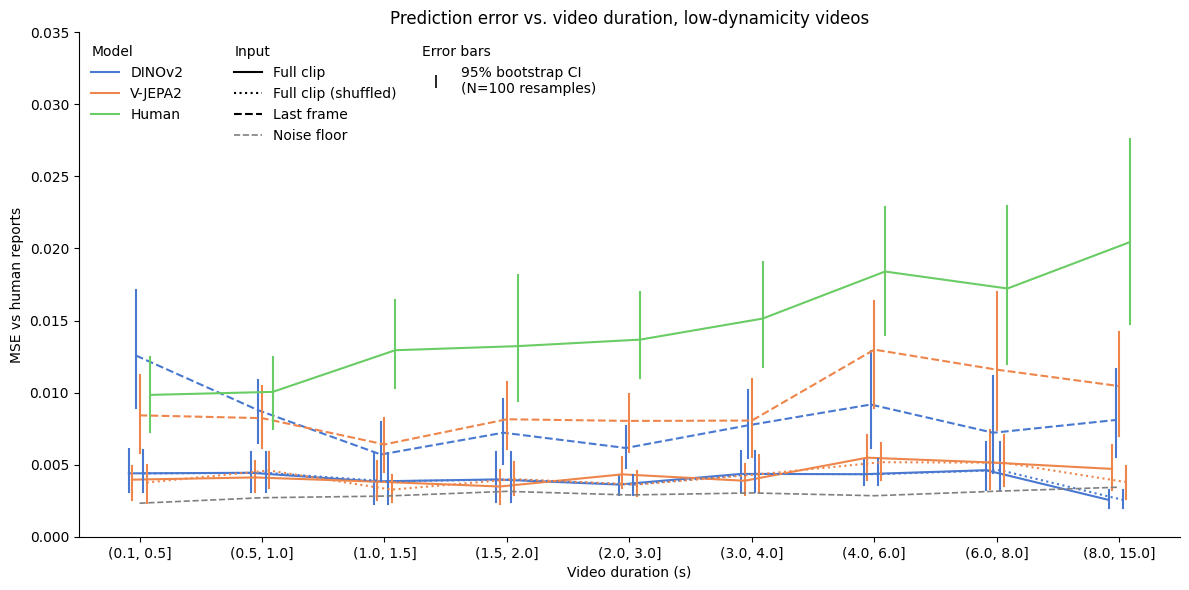

In [228]:
from matplotlib.lines import Line2D

hue_order = [cfg['col'] for cfg in model_configs] + ['frame_prediction']

palette = sns.color_palette('muted', 3)
model_colors = {
    'Frame based model': palette[0],   # DINOv2
    'Video based model': palette[1],   # V-JEPA2
}
colors = [model_colors[cfg['kind']] for cfg in model_configs]
colors += [palette[2]]        # human final-frame baseline
noise_color = 'grey'

view_linestyles = {'full_clip': '-', 'shuffled': ':', 'last_frame': '--'}
linestyles = [view_linestyles[cfg['view']] for cfg in model_configs] + ['-']  # human: solid

g = sns.catplot(
    data=df_boots,
    x='videoDuration_bins',
    y='mse',
    kind='point',
    errorbar=('pi', 95),
    hue='predictor',
    hue_order=hue_order,
    palette=colors,
    markers='o',
    markersize=0,
    linewidth=1.5,
    linestyles=linestyles,
    dodge=True,
    legend=False,
    aspect=2,
    height=6,
)

nf_mean = noise_floor_df.groupby('kind')['Reliability'].mean().reset_index()
ax = g.axes[0][0]
ax.plot(
    range(len(nf_mean)),
    nf_mean['Reliability'].values,
    color=noise_color, linestyle='--', linewidth=1.2,
)

g.set(ylim=(0.00, 0.035))   # revisit once you see the shuffled curves — may need to raise this
g.set_xlabels('Video duration (s)')
g.set_ylabels('MSE vs human reports')

model_legend_elements = [
    Line2D([0], [0], color=model_colors['Frame based model'], lw=1.5, label='DINOv2'),
    Line2D([0], [0], color=model_colors['Video based model'], lw=1.5, label='V-JEPA2'),
    Line2D([0], [0], color=palette[2], lw=1.5, label='Human'),
]

view_legend_elements = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Full clip'),
    Line2D([0], [0], color='black', lw=1.5, linestyle=':', label='Full clip (shuffled)'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Last frame'),
    Line2D([0], [0], color=noise_color, lw=1.2, linestyle='--', label='Noise floor'),
]

error_bar_proxy = ax.errorbar(
    [], [], yerr=[], fmt='none', ecolor='black', elinewidth=1.2, capsize=3,
    label='95% bootstrap CI\n(N=100 resamples)'
)

legend1 = ax.legend(handles=model_legend_elements, loc='upper left',
                     frameon=False, title='Model', alignment='left')
ax.add_artist(legend1)

legend2 = ax.legend(handles=view_legend_elements, loc='upper left', bbox_to_anchor=(0.13, 1.0),
                     frameon=False, title='Input', alignment='left')
ax.add_artist(legend2)

legend3 = ax.legend(handles=[error_bar_proxy], loc='upper left', bbox_to_anchor=(0.30, 1.0),
                     frameon=False, title='Error bars', alignment='left')


if low_dynamicity_filter:
    ax.set_title("Prediction error vs. video duration, low-dynamicity videos")
else:
    ax.set_title("Prediction error vs. video duration")

plt.tight_layout()
plt.show()

## Experiment 3: 

### 1. MSE gap between one-frame and full-frame model as a function of video duration, for both frame & video-based

In [158]:
# --- Per-video squared error: shuffled vs. ordered full-clip, for each model ---
full_clip_col = 'dinov2_prediction'
shuffled_col  = 'dinov2_shuffled_prediction'

test_df['sq_err_full']     = (test_df[full_clip_col] - test_df['prediction'])**2
test_df['sq_err_shuffled'] = (test_df[shuffled_col]  - test_df['prediction'])**2

video_mse_dino = test_df.groupby(['Video_ID', 'videoDuration_bins'], as_index=False, observed=True).agg(
    mse_full=('sq_err_full', 'mean'),
    mse_shuffled=('sq_err_shuffled', 'mean'),
)
video_mse_dino['mse_gap'] = video_mse_dino['mse_shuffled'] - video_mse_dino['mse_full']

full_clip_video_col = 'v_jepa2_prediction'
shuffled_video_col  = 'v_jepa2_shuffled_prediction'

test_df['sq_err_full_video']     = (test_df[full_clip_video_col] - test_df['prediction'])**2
test_df['sq_err_shuffled_video'] = (test_df[shuffled_video_col]  - test_df['prediction'])**2

video_mse_vjepa = test_df.groupby(['Video_ID', 'videoDuration_bins'], as_index=False, observed=True).agg(
    mse_full=('sq_err_full_video', 'mean'),
    mse_shuffled=('sq_err_shuffled_video', 'mean'),
)
video_mse_vjepa['mse_gap'] = video_mse_vjepa['mse_shuffled'] - video_mse_vjepa['mse_full']

video_gap_shuffle_df = video_mse_dino.merge(
    video_mse_vjepa[['Video_ID', 'mse_gap']].rename(columns={'mse_gap': 'gap_video_model'}),
    on='Video_ID', how='inner'
).rename(columns={'mse_gap': 'gap_frame_model'})[
    ['Video_ID', 'videoDuration_bins', 'gap_frame_model', 'gap_video_model']
]

video_gap_shuffle_df.head()

,Video_ID,videoDuration_bins,gap_frame_model,gap_video_model
0,0089fd8c-1b30-468e-b0c9-98d265e4d705,"(6.0, 8.0]",-1.736431e-07,0.000234
1,00dec6a0-dd5f-4024-91cf-a4b7c92d1242,"(3.0, 4.0]",-9.013903e-07,0.006138
2,013a7ba7-f8e0-43c3-81f6-bece27b33a67,"(6.0, 8.0]",-3.629816e-06,-0.001872
3,01d2c4da-c76c-4498-98fd-81d2e712e5eb,"(3.0, 4.0]",-1.449637e-06,-0.000322
4,01f812c8-a0ed-42aa-8c3e-71eed10c9323,"(4.0, 6.0]",-8.594794e-07,-0.002665


In [159]:
# --- Bootstrap across videos, within each duration bin ---
gap_boots_shuffle = []
for b in range(repetitions):
    boot = video_gap_shuffle_df.groupby('videoDuration_bins', observed=True).sample(frac=1, replace=True)
    means = boot.groupby('videoDuration_bins', as_index=False, observed=True)[
        ['gap_frame_model', 'gap_video_model']
    ].mean()
    means_long = means.melt(
        id_vars='videoDuration_bins', value_vars=['gap_frame_model', 'gap_video_model'],
        var_name='model', value_name='mse_gap'
    )
    means_long['b'] = b
    gap_boots_shuffle.append(means_long)

gap_boots_shuffle = pd.concat(gap_boots_shuffle, ignore_index=True)

# Locally-scoped label dict -- avoids reusing/overwriting the shared `model_labels`
# variable that's caused mismatches elsewhere in this notebook
shuffle_model_labels = {
    'gap_frame_model': 'DINOv2',
    'gap_video_model': 'V-JEPA2',
}
gap_boots_shuffle['model'] = gap_boots_shuffle['model'].map(shuffle_model_labels)

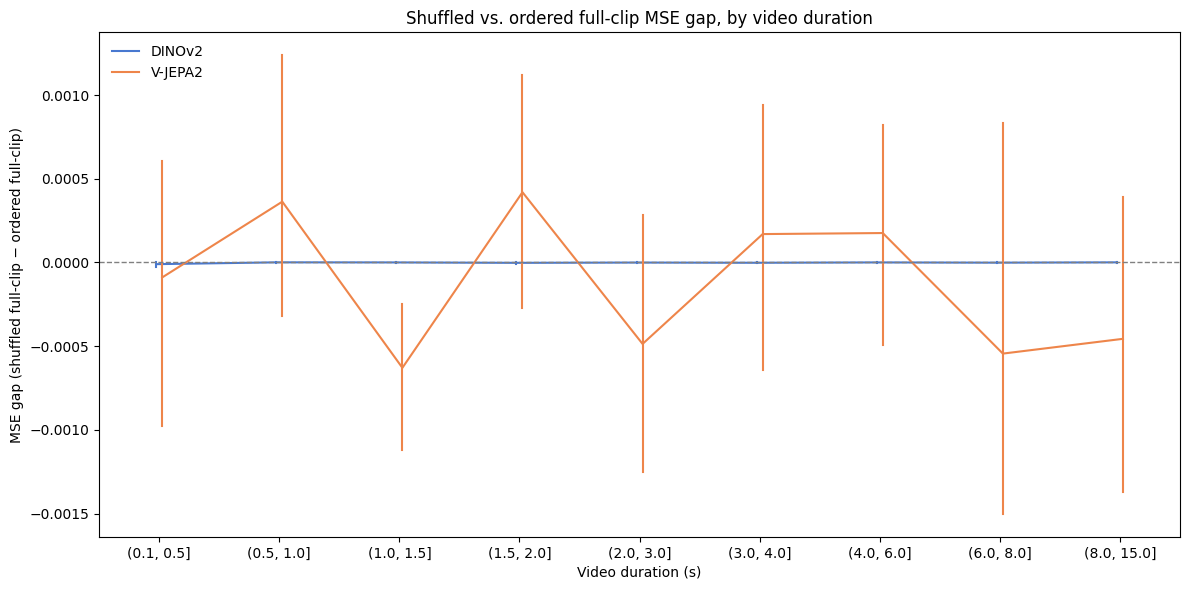

In [160]:
# --- Plot ---
plt.figure(figsize=(12, 6))

full_clip_colors = [model_colors['Frame based model'], model_colors['Video based model']]

sns.pointplot(
    data=gap_boots_shuffle,
    x='videoDuration_bins',
    y='mse_gap',
    hue='model',
    hue_order=['DINOv2', 'V-JEPA2'],
    palette=full_clip_colors,
    errorbar=('pi', 95),
    markers='o',
    markersize=0,
    linewidth=1.5,
    dodge=True,
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Video duration (s)')
plt.ylabel('MSE gap (shuffled full-clip − ordered full-clip)')
if low_dynamicity_filter:
    plt.title('Shuffled vs. ordered full-clip MSE gap, by video duration, restricted to low dynamicity videos')
else:
    plt.title('Shuffled vs. ordered full-clip MSE gap, by video duration')
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

### 2. Normalized MSE gap between one-frame and full-frame model as a function of video duration, for both frame & video-based

In [178]:
eps = 1e-8  # avoid divide-by-zero when mse_full ≈ 0

video_mse_dino['mse_gap'] = (
    (video_mse_dino['mse_shuffled'] - video_mse_dino['mse_full'])
    / (video_mse_dino['mse_full'] + eps)
)

video_mse_vjepa['mse_gap'] = (
    (video_mse_vjepa['mse_shuffled'] - video_mse_vjepa['mse_full'])
    / (video_mse_vjepa['mse_full'] + eps)
)

video_gap_shuffle_df = video_mse_dino.merge(
    video_mse_vjepa[['Video_ID', 'mse_gap']].rename(columns={'mse_gap': 'gap_video_model'}),
    on='Video_ID', how='inner'
).rename(columns={'mse_gap': 'gap_frame_model'})[
    ['Video_ID', 'videoDuration_bins', 'gap_frame_model', 'gap_video_model']
]

video_gap_shuffle_df.head()

,Video_ID,videoDuration_bins,gap_frame_model,gap_video_model
0,0089fd8c-1b30-468e-b0c9-98d265e4d705,"(6.0, 8.0]",-0.000661,1.239766
1,00dec6a0-dd5f-4024-91cf-a4b7c92d1242,"(3.0, 4.0]",-0.000470,1.712415
2,013a7ba7-f8e0-43c3-81f6-bece27b33a67,"(6.0, 8.0]",-0.000695,-0.633726
3,01d2c4da-c76c-4498-98fd-81d2e712e5eb,"(3.0, 4.0]",-0.000306,-0.105843
4,01f812c8-a0ed-42aa-8c3e-71eed10c9323,"(4.0, 6.0]",-0.000118,-0.201727


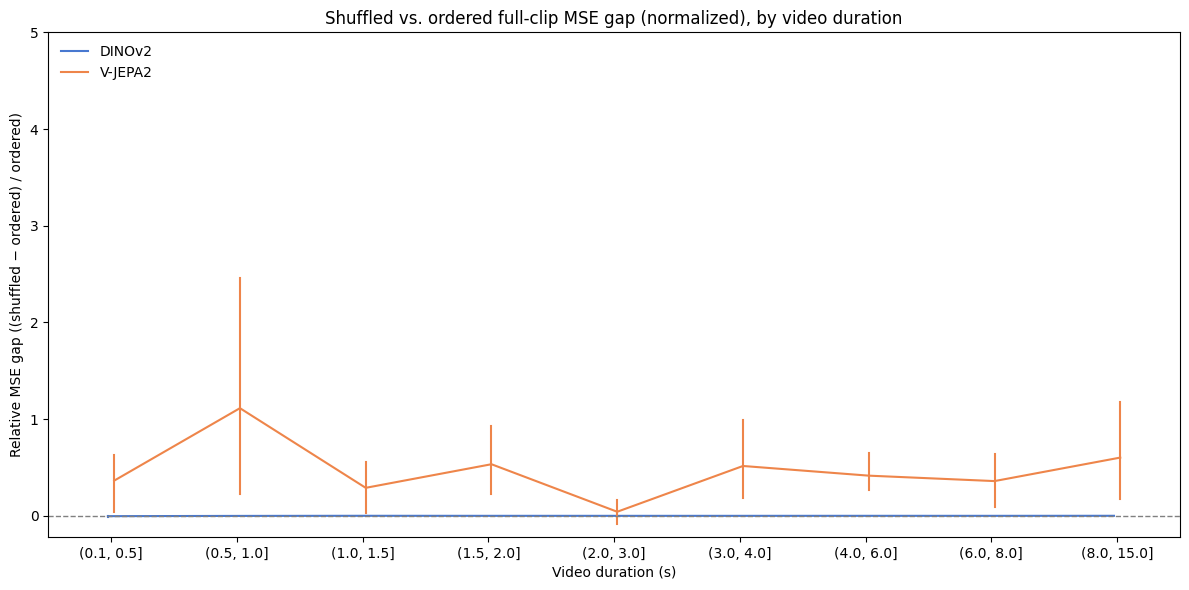

In [179]:
# --- Bootstrap across videos, within each duration bin ---
gap_boots_shuffle = []
for b in range(repetitions):
    boot = video_gap_shuffle_df.groupby('videoDuration_bins', observed=True).sample(frac=1, replace=True)
    means = boot.groupby('videoDuration_bins', as_index=False, observed=True)[
        ['gap_frame_model', 'gap_video_model']
    ].mean()
    means_long = means.melt(
        id_vars='videoDuration_bins', value_vars=['gap_frame_model', 'gap_video_model'],
        var_name='model', value_name='mse_gap'
    )
    means_long['b'] = b
    gap_boots_shuffle.append(means_long)

gap_boots_shuffle = pd.concat(gap_boots_shuffle, ignore_index=True)

# Locally-scoped label dict -- avoids reusing/overwriting the shared `model_labels`
# variable that's caused mismatches elsewhere in this notebook
shuffle_model_labels = {
    'gap_frame_model': 'DINOv2',
    'gap_video_model': 'V-JEPA2',
}
gap_boots_shuffle['model'] = gap_boots_shuffle['model'].map(shuffle_model_labels)

# --- Plot ---
plt.figure(figsize=(12, 6))

full_clip_colors = [model_colors['Frame based model'], model_colors['Video based model']]

sns.pointplot(
    data=gap_boots_shuffle,
    x='videoDuration_bins',
    y='mse_gap',
    hue='model',
    hue_order=['DINOv2', 'V-JEPA2'],
    palette=full_clip_colors,
    errorbar=('pi', 95),
    markers='o',
    markersize=0,
    linewidth=1.5,
    dodge=True,
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Video duration (s)')
plt.ylabel('Relative MSE gap ((shuffled − ordered) / ordered)')
plt.ylim(top=5)
plt.title('Shuffled vs. ordered full-clip MSE gap (normalized), by video duration')
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

  videoDuration_bins  mean_diff     ci_lo     ci_hi  excludes_zero
0         (0.1, 0.5]   0.363987  0.028812  0.717981           True
1         (0.5, 1.0]   1.169392  0.172447  2.553560           True
2         (1.0, 1.5]   0.281222  0.049617  0.580327           True
3         (1.5, 2.0]   0.532435  0.162486  0.895679           True
4         (2.0, 3.0]   0.046785 -0.087872  0.166533          False
5         (3.0, 4.0]   0.586798  0.259979  1.011986           True
6         (4.0, 6.0]   0.400277  0.241901  0.573361           True
7         (6.0, 8.0]   0.364221  0.106603  0.649341           True
8        (8.0, 15.0]   0.604967  0.116611  1.119176           True


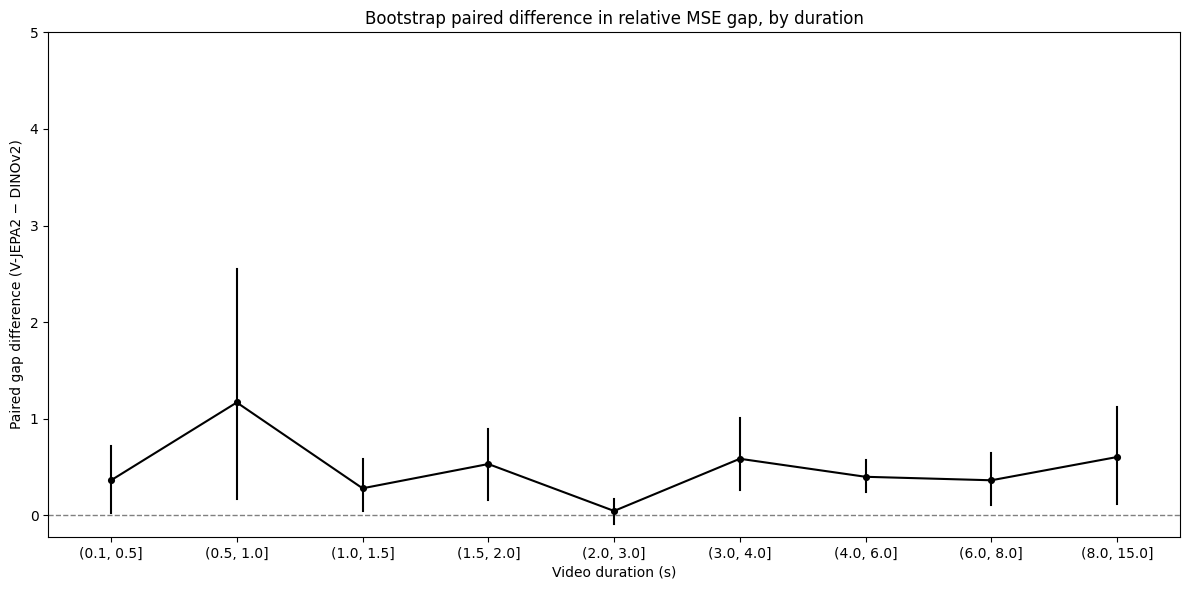

Overall paired diff (V-JEPA2 - DINOv2): mean=0.477, 95% CI=(0.299, 0.650), excludes zero: True


In [180]:
video_gap_shuffle_df = video_gap_shuffle_df.copy()
video_gap_shuffle_df['gap_diff'] = (
    video_gap_shuffle_df['gap_video_model'] - video_gap_shuffle_df['gap_frame_model']
)

diff_boots = []
for b in range(repetitions):
    boot = video_gap_shuffle_df.groupby('videoDuration_bins', observed=True).sample(
        frac=1, replace=True
    )
    means = boot.groupby('videoDuration_bins', as_index=False, observed=True)['gap_diff'].mean()
    means['b'] = b
    diff_boots.append(means)

diff_boots = pd.concat(diff_boots, ignore_index=True)

# %%
def summarize_ci(g, col='gap_diff', pct=95):
    lo, hi = np.percentile(g[col], [(100 - pct) / 2, 100 - (100 - pct) / 2])
    return pd.Series({'mean_diff': g[col].mean(), 'ci_lo': lo, 'ci_hi': hi})

diff_summary = (
    diff_boots.groupby('videoDuration_bins', observed=True)
    .apply(summarize_ci, include_groups=False)
    .reset_index()
)
diff_summary['excludes_zero'] = (diff_summary['ci_lo'] > 0) | (diff_summary['ci_hi'] < 0)
print(diff_summary)

# %%
plt.figure(figsize=(12, 6))
sns.pointplot(
    data=diff_boots,
    x='videoDuration_bins',
    y='gap_diff',
    errorbar=('pi', 95),
    color='black',
    markers='o',
    markersize=4,
    linewidth=1.5,
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.ylim(top=5)
plt.xlabel('Video duration (s)')
plt.ylabel('Paired gap difference (V-JEPA2 − DINOv2)')
plt.title('Bootstrap paired difference in relative MSE gap, by duration')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Overall (pooled) paired difference, not split by duration
#
# One headline number: is V-JEPA2's gap greater than DINOv2's overall?

# %%
overall_diffs = np.array([
    video_gap_shuffle_df.sample(frac=1, replace=True)['gap_diff'].mean()
    for _ in range(repetitions)
])
ci_lo, ci_hi = np.percentile(overall_diffs, [2.5, 97.5])
print(
    f"Overall paired diff (V-JEPA2 - DINOv2): "
    f"mean={overall_diffs.mean():.3f}, 95% CI=({ci_lo:.3f}, {ci_hi:.3f}), "
    f"excludes zero: {(ci_lo > 0) or (ci_hi < 0)}"
)

In [181]:
test_df_full = load_humanReportRates('test')
test_df_full['videoDuration_bins'], _ = pd.cut(test_df_full['videoDuration (sec)'], bins=duration_bins, retbins=True)
test_df_full = test_df_full.melt(
    id_vars=['video_type', 'File_name', 'stimulus_video_url',
             'Video_ID', 'videoDuration (sec)', 'video_number', 'videoDuration_bins', 'n_clusters'],
    value_vars=categories, var_name='category', value_name='prediction'
)
test_df_full['tmp'] = test_df_full['File_name'] + '_' + test_df_full['category']

for cfg in model_configs:
    preds = pd.read_csv(cfg['csv'])
    preds['tmp'] = preds['videoID'] + '_' + preds['category']
    test_df_full[cfg['col']] = test_df_full['tmp'].map(dict(zip(preds['tmp'], preds['prediction']))).clip(0, 1)

In [182]:
import glob

VJEPA_SHUFFLE_DIR = '/braintree/home/aicha/part_2/vjepa2_h1_shuffled/'
vjepa_seeds = pd.concat(
    [pd.read_csv(f) for f in sorted(glob.glob(VJEPA_SHUFFLE_DIR + 'vjepa2_shuffled_seed*.csv'))],
    ignore_index=True
)
vjepa_seeds['tmp'] = vjepa_seeds['videoID'] + '_' + vjepa_seeds['category']

gt_lookup      = dict(zip(test_df_full['tmp'], test_df_full['prediction']))
ordered_lookup = dict(zip(test_df_full['tmp'], test_df_full['v_jepa2_prediction']))

vjepa_seeds['true_label']         = vjepa_seeds['tmp'].map(gt_lookup)
vjepa_seeds['ordered_prediction'] = vjepa_seeds['tmp'].map(ordered_lookup)
print(vjepa_seeds[['true_label', 'ordered_prediction']].isna().sum(), "unmatched")  # sanity check

vjepa_seeds['sq_err_shuffled'] = (vjepa_seeds['prediction']         - vjepa_seeds['true_label'])**2
vjepa_seeds['sq_err_full']     = (vjepa_seeds['ordered_prediction'] - vjepa_seeds['true_label'])**2

per_video_seed_vjepa = vjepa_seeds.groupby(['videoID', 'seed'], as_index=False).agg(
    mse_shuffled=('sq_err_shuffled', 'mean'),
    mse_full=('sq_err_full', 'mean'),
)
per_video_seed_vjepa['mse_gap'] = per_video_seed_vjepa['mse_shuffled'] - per_video_seed_vjepa['mse_full']

true_label            0
ordered_prediction    0
dtype: int64 unmatched


In [183]:
video_gap_vjepa = per_video_seed_vjepa.groupby('videoID', as_index=False).agg(
    mean_gap=('mse_gap', 'mean'),
    std_gap=('mse_gap', 'std'),
    n_seeds=('mse_gap', 'count'),
)
video_gap_vjepa['gap_se']      = video_gap_vjepa['std_gap'] / np.sqrt(video_gap_vjepa['n_seeds'])
video_gap_vjepa['t_stat']      = video_gap_vjepa['mean_gap'] / video_gap_vjepa['gap_se']
video_gap_vjepa['consistent']  = video_gap_vjepa['t_stat'].abs() > 2  # gap sign holds up across seeds, not just noise
video_gap_vjepa['model']       = 'V-JEPA2'

In [184]:
test_df_full['sq_err_full_dino']     = (test_df_full['dinov2_prediction']          - test_df_full['prediction'])**2
test_df_full['sq_err_shuffled_dino'] = (test_df_full['dinov2_shuffled_prediction'] - test_df_full['prediction'])**2

video_gap_dino = test_df_full.groupby('Video_ID', as_index=False).agg(
    mse_full=('sq_err_full_dino', 'mean'),
    mse_shuffled=('sq_err_shuffled_dino', 'mean'),
).rename(columns={'Video_ID': 'videoID'})
video_gap_dino['mean_gap'] = video_gap_dino['mse_shuffled'] - video_gap_dino['mse_full']
video_gap_dino['n_seeds'] = 1
video_gap_dino['model'] = 'DINOv2'

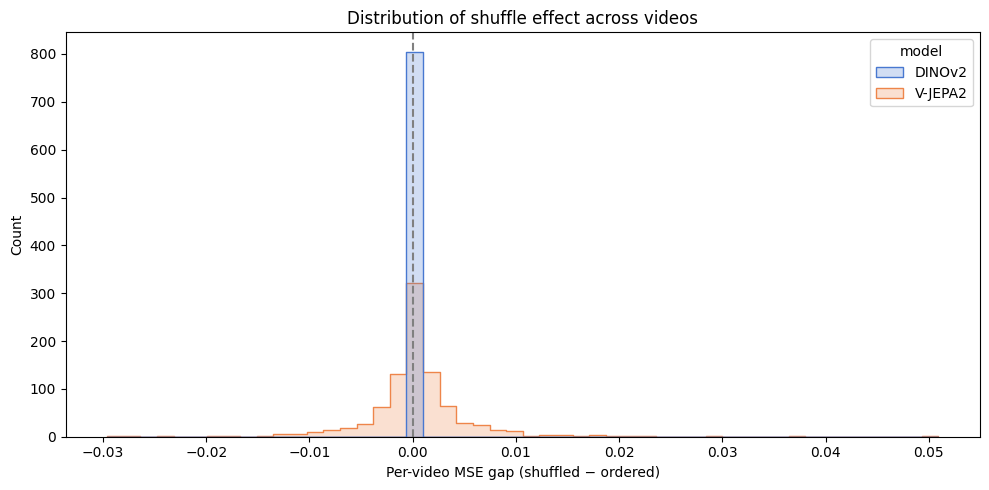

In [185]:
combined = pd.concat([
    video_gap_dino[['videoID', 'mean_gap', 'n_seeds', 'model']],
    video_gap_vjepa[['videoID', 'mean_gap', 'n_seeds', 'model']],
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=combined, x='mean_gap', hue='model', bins=50, element='step', stat='count',
    palette=[model_colors['Frame based model'], model_colors['Video based model']],
)
ax.axvline(0, color='grey', linestyle='--')
ax.set_xlabel('Per-video MSE gap (shuffled − ordered)')
ax.set_title('Distribution of shuffle effect across videos')
plt.tight_layout()
plt.show()

In [186]:
dino_noise_scale = video_gap_dino['mean_gap'].std()
print(f"DINOv2 residual noise (should be ~0 architecturally): std = {dino_noise_scale:.2e}")

zero_thresh = 3 * dino_noise_scale  # V-JEPA2 gaps smaller than 3x pure measurement noise

DINOv2 residual noise (should be ~0 architecturally): std = 1.41e-05


380 videos near-zero gap, 522 not
380 902
3       100_5a78054e-d6c5-4a22-a0dc-cb608affb8c3
6       101_8d6a1089-4eb7-4dca-97eb-9480331470f7
7       101_e28197fe-d72c-4c61-be65-d224a53a7f63
9     10208_2413dce7-2c3e-43cd-8482-fbc3ed465adf
10    10252_df31a646-4ee1-428a-bb97-1d1e872c8d37
Name: videoID, dtype: object
                                File_name  videoDuration (sec)
0  0_540c91d9-37a9-4148-bf24-3418feb7e212                 3.69
1  0_cc0bc490-f2cb-4b7a-b5e1-9dba9e58af1a                 6.45
2  1_1632026f-3946-4c64-bcb1-3a1e75653638                 9.05
3  1_f092ee63-a551-4134-8071-0b7d8d3b12fc                 3.91
4  2_ca420a87-f940-4bbf-89da-c0d606acda08                 6.18
380


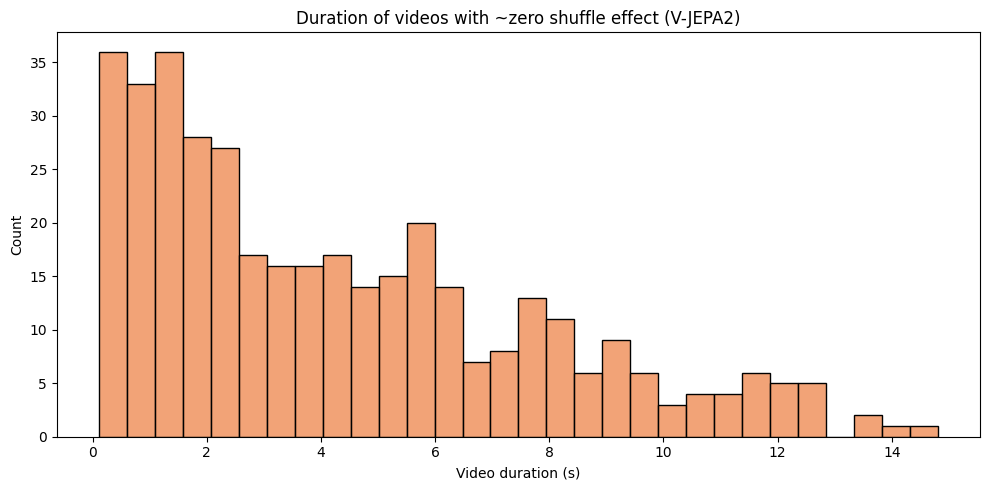

In [187]:
# "Zero gap" in practice means a threshold, not exact 0.0 (continuous values almost never land exactly on it)
zero_thresh = 1e-3 # adjust based on the scale you're seeing in mean_gap

zero_gap_videos = video_gap_vjepa[video_gap_vjepa['mean_gap'].abs() < zero_thresh]
nonzero_gap_videos = video_gap_vjepa[video_gap_vjepa['mean_gap'].abs() >= zero_thresh]

print(f"{len(zero_gap_videos)} videos near-zero gap, {len(nonzero_gap_videos)} not")

# bring in duration (dedupe test_df_full to one row per video first)
video_meta = test_df_full[['File_name', 'videoDuration (sec)']].drop_duplicates()

zero_gap_merged    = zero_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')
nonzero_gap_merged = nonzero_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')


print(len(zero_gap_videos), len(video_meta))
print(zero_gap_videos['videoID'].head())
print(video_meta.head())
print(len(zero_gap_merged))  # <- if this is 0, that's your answer

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(zero_gap_merged['videoDuration (sec)'], bins=30, ax=ax, color=model_colors['Video based model'])
ax.set_xlabel('Video duration (s)')
ax.set_title('Duration of videos with ~zero shuffle effect (V-JEPA2)')
plt.tight_layout()
plt.show()

In [216]:
negative_gap_videos = video_gap_vjepa[video_gap_vjepa['mean_gap'] < 0]
positive_gap_videos = video_gap_vjepa[video_gap_vjepa['mean_gap'] >= 0]

print(f"{len(negative_gap_videos)} / {len(video_gap_vjepa)} videos with negative shuffle effect (shuffling improved MSE)")

negative_gap_merged = negative_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')
positive_gap_merged = positive_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')

411 / 902 videos with negative shuffle effect (shuffling improved MSE)


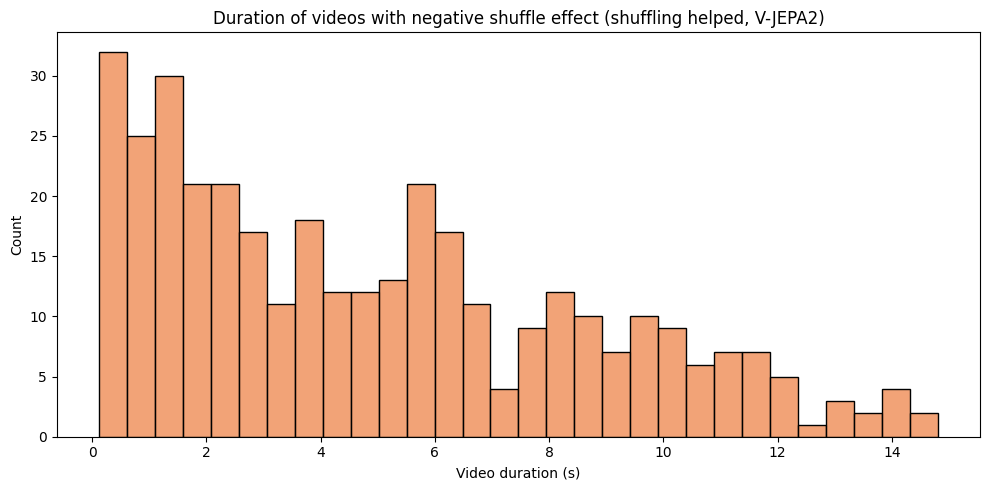

In [217]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(negative_gap_merged['videoDuration (sec)'], bins=30, ax=ax, color=model_colors['Video based model'])
ax.set_xlabel('Video duration (s)')
ax.set_title('Duration of videos with negative shuffle effect (shuffling helped, V-JEPA2)')
plt.tight_layout()
plt.show()

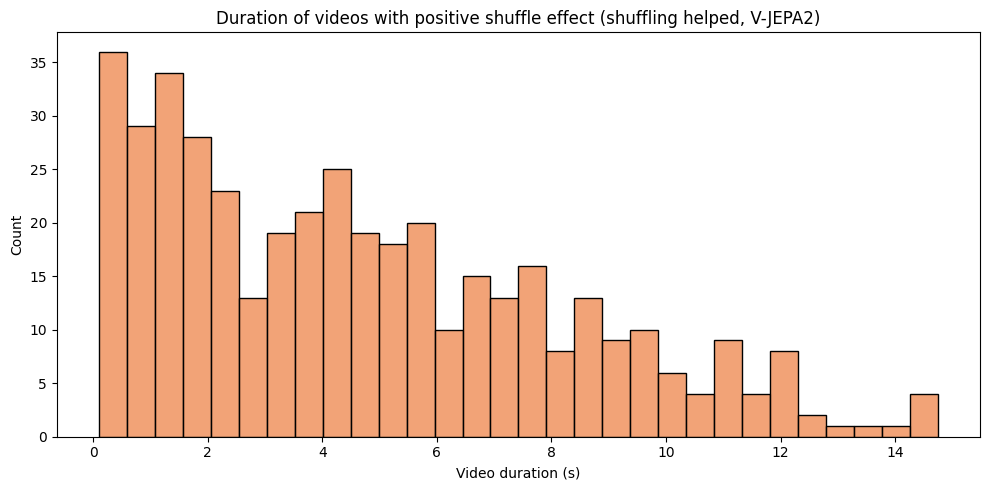

In [218]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(positive_gap_merged['videoDuration (sec)'], bins=30, ax=ax, color=model_colors['Video based model'])
ax.set_xlabel('Video duration (s)')
ax.set_title('Duration of videos with positive shuffle effect (shuffling helped, V-JEPA2)')
plt.tight_layout()
plt.show()

['videoID', 'mean_gap', 'std_gap', 'n_seeds', 'gap_se', 't_stat', 'consistent', 'model', 'File_name', 'n_clusters']


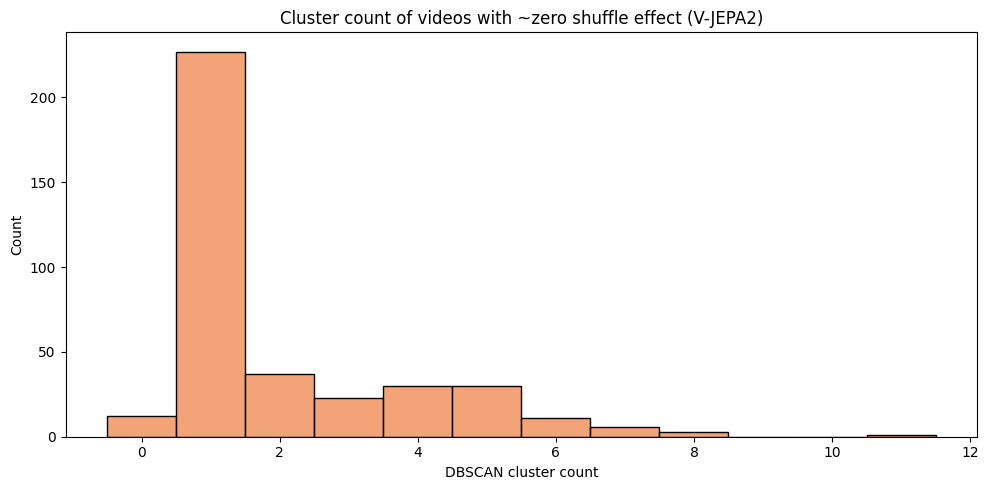

In [192]:
video_meta = test_df_full[['File_name', 'n_clusters']].drop_duplicates()

zero_gap_merged    = zero_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')
nonzero_gap_merged = nonzero_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')

print(zero_gap_merged.columns.tolist())  # confirm 'n_clusters' is actually there before plotting

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    zero_gap_merged['n_clusters'], discrete=True, ax=ax,
    color=model_colors['Video based model'],
)
ax.set_xlabel('DBSCAN cluster count')
ax.set_title('Cluster count of videos with ~zero shuffle effect (V-JEPA2)')
plt.tight_layout()
plt.show()

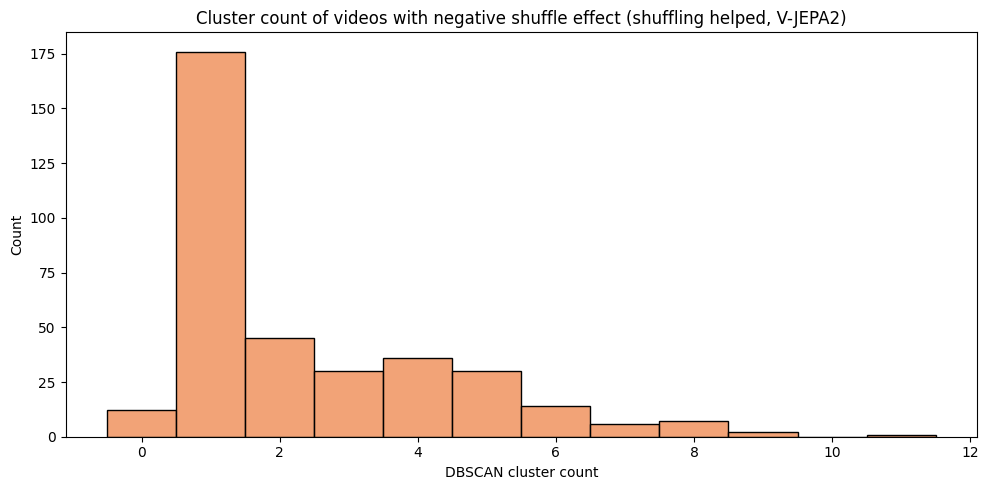

In [205]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    negative_gap_merged['n_clusters'], discrete=True, ax=ax,
    color=model_colors['Video based model'],
)
ax.set_xlabel('DBSCAN cluster count')
ax.set_title('Cluster count of videos with negative shuffle effect (shuffling helped, V-JEPA2)')
plt.tight_layout()
plt.show()

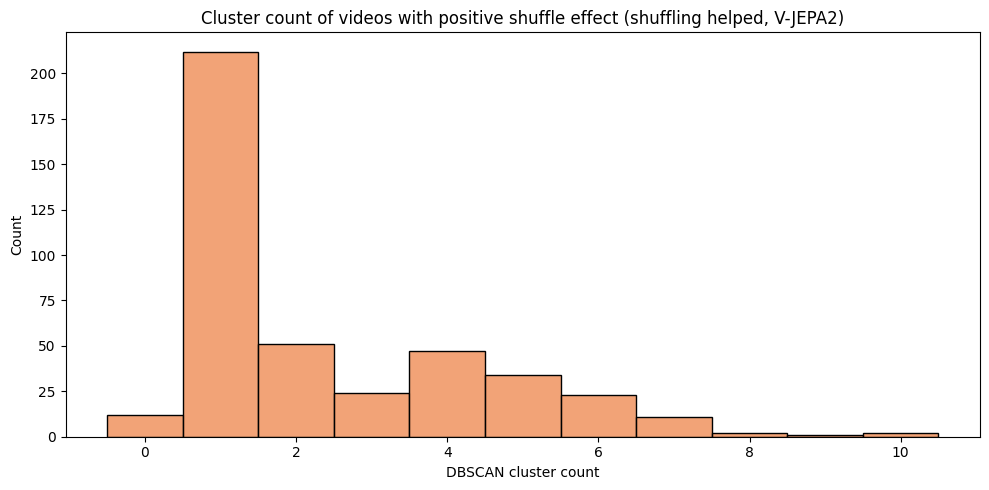

In [219]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    positive_gap_merged['n_clusters'], discrete=True, ax=ax,
    color=model_colors['Video based model'],
)
ax.set_xlabel('DBSCAN cluster count')
ax.set_title('Cluster count of videos with positive shuffle effect (shuffling helped, V-JEPA2)')
plt.tight_layout()
plt.show()

['videoID', 'mean_gap', 'std_gap', 'n_seeds', 'gap_se', 't_stat', 'consistent', 'model', 'File_name', 'n_clusters', 'videoDuration (sec)']


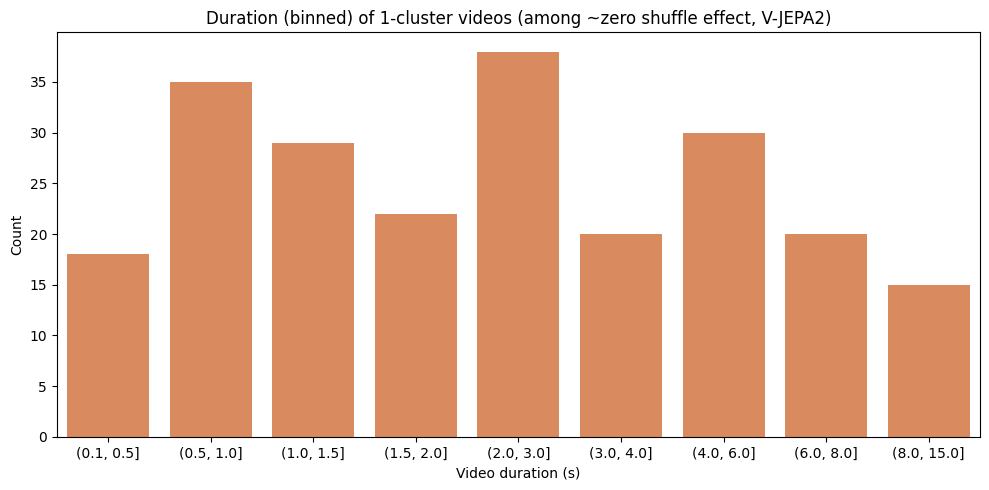

In [195]:
video_meta = test_df_full[['File_name', 'n_clusters', 'videoDuration (sec)']].drop_duplicates()

zero_gap_merged    = zero_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')
nonzero_gap_merged = nonzero_gap_videos.merge(video_meta, left_on='videoID', right_on='File_name')

print(zero_gap_merged.columns.tolist())  # confirm both are present now

one_cluster_videos = zero_gap_merged[zero_gap_merged['n_clusters'] == 1].copy()
one_cluster_videos['videoDuration_bins'], _ = pd.cut(
    one_cluster_videos['videoDuration (sec)'], bins=duration_bins, retbins=True
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(
    data=one_cluster_videos, x='videoDuration_bins', ax=ax,
    color=model_colors['Video based model'],
)
ax.set_xlabel('Video duration (s)')
ax.set_ylabel('Count')
ax.set_title('Duration (binned) of 1-cluster videos (among ~zero shuffle effect, V-JEPA2)')
plt.tight_layout()
plt.show()

In [211]:
# --- 2. Rebuild raw (non-normalized) gap fresh from mse_full/mse_shuffled, restrict to n_clusters >= 2 ---
video_mse_dino['raw_gap']  = video_mse_dino['mse_shuffled']  - video_mse_dino['mse_full']
video_mse_vjepa['raw_gap'] = video_mse_vjepa['mse_shuffled'] - video_mse_vjepa['mse_full']

video_gap_shuffle_df_dynamic = video_mse_dino.merge(
    video_mse_vjepa[['Video_ID', 'raw_gap']].rename(columns={'raw_gap': 'gap_video_model'}),
    on='Video_ID', how='inner'
).rename(columns={'raw_gap': 'gap_frame_model'})[
    ['Video_ID', 'videoDuration_bins', 'gap_frame_model', 'gap_video_model']
]

video_gap_shuffle_df_dynamic = video_gap_shuffle_df_dynamic.merge(
    video_meta[['Video_ID', 'n_clusters']], on='Video_ID', how='left'
)
video_gap_shuffle_df_dynamic = video_gap_shuffle_df_dynamic[video_gap_shuffle_df_dynamic['n_clusters'] != 1]

print(f"{len(video_gap_shuffle_df_dynamic)} videos with 0 or >=2 clusters")
print(video_gap_shuffle_df_dynamic.groupby('videoDuration_bins', observed=True).size())

580 videos with 0 or >=2 clusters
videoDuration_bins
(0.1, 0.5]      39
(0.5, 1.0]      18
(1.0, 1.5]      19
(1.5, 2.0]      31
(2.0, 3.0]      39
(3.0, 4.0]      48
(4.0, 6.0]     122
(6.0, 8.0]      98
(8.0, 15.0]    166
dtype: int64


In [212]:
# --- 4. Bootstrap across videos, within each duration bin ---
gap_boots_shuffle_dynamic = []
for b in range(repetitions):
    boot = video_gap_shuffle_df_dynamic.groupby('videoDuration_bins', observed=True).sample(frac=1, replace=True)
    means = boot.groupby('videoDuration_bins', as_index=False, observed=True)[
        ['gap_frame_model', 'gap_video_model']
    ].mean()
    means_long = means.melt(
        id_vars='videoDuration_bins', value_vars=['gap_frame_model', 'gap_video_model'],
        var_name='model', value_name='mse_gap'
    )
    means_long['b'] = b
    gap_boots_shuffle_dynamic.append(means_long)

gap_boots_shuffle_dynamic = pd.concat(gap_boots_shuffle_dynamic, ignore_index=True)
gap_boots_shuffle_dynamic['model'] = gap_boots_shuffle_dynamic['model'].map(shuffle_model_labels)

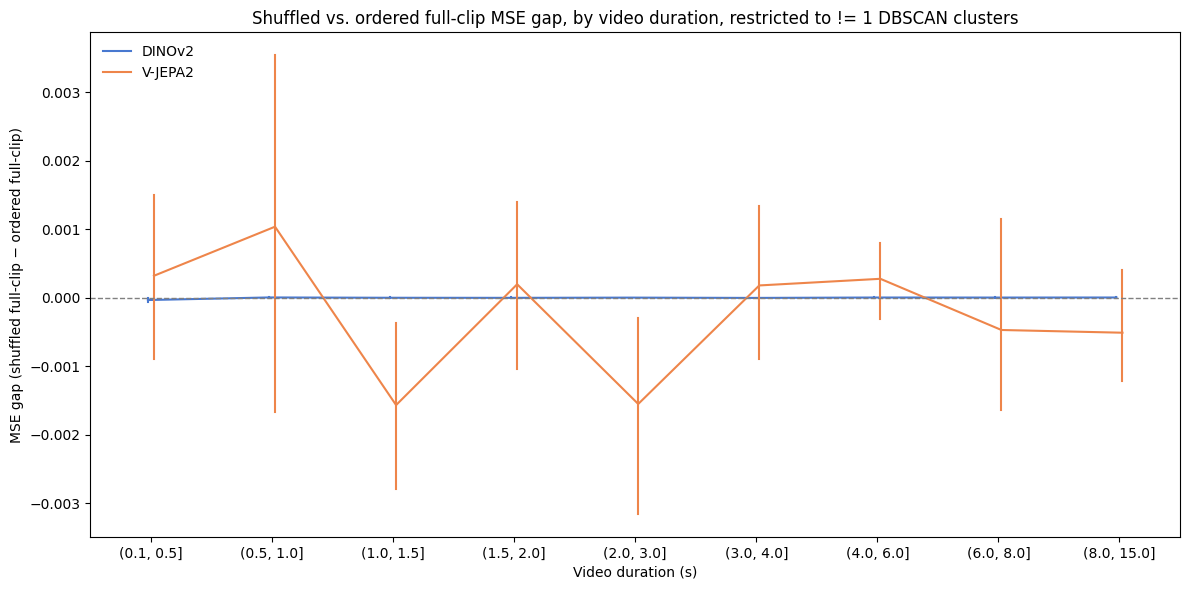

In [214]:
# --- 5. Plot ---
plt.figure(figsize=(12, 6))

sns.pointplot(
    data=gap_boots_shuffle_dynamic,
    x='videoDuration_bins',
    y='mse_gap',
    hue='model',
    hue_order=['DINOv2', 'V-JEPA2'],
    palette=full_clip_colors,
    errorbar=('pi', 95),
    markers='o',
    markersize=0,
    linewidth=1.5,
    dodge=True,
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Video duration (s)')
plt.ylabel('MSE gap (shuffled full-clip − ordered full-clip)')
plt.title('Shuffled vs. ordered full-clip MSE gap, by video duration, restricted to != 1 DBSCAN clusters')
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()